# FREQ

# Amout

In [1]:
 
from utils_functions import (run_step,
                             Model_Prediction_Amount)

In [2]:

amount = Model_Prediction_Amount()
metadata_amount_loaded = {}

metadata_amount_loaded = run_step('Lecture des métadonnées de l\'artefact pipeline Amount',
                                    amount.read_artifact_metadata,
                                    'sorties/pipeline/pipeline_amount.pickle')
print("\n[METADATA PIPELINE AMOUNT]")
for key, value in metadata_amount_loaded.items():
    print(f"{key}: {value}")

print("\n[PREDICTIF TEST - AMOUNT]")
print(f"metrics_test: {metadata_amount_loaded.get('metrics_test')}")
print(f"prediction_test_sample_top10: {metadata_amount_loaded.get('prediction_test_sample_top10')}")

Lecture des métadonnées de l'artefact pipeline Amount:   0%|           | 0/1 • 00:00 < ?


[METADATA PIPELINE AMOUNT]
saved_at: 2026-02-22T13:40:02.957929
target: montant_sinistre
created_at: 2026-02-22T14:40:02.956441
metrics_valid: {'RMSE': np.float64(366.32067866621816), 'MSE': 134190.83961847867}
metrics_train: {'RMSE': np.float64(350.18504187673483), 'MSE': 122629.56355421052}
metrics_test: {'count_predictions': 50000, 'pred_mean': 0.15064254278352554, 'pred_std': 6.822956592486513, 'pred_min': -55.10665366005864, 'pred_max': 17.39089924266333}
overfitting_amount: {'rmse_gap_train_minus_valid': np.float64(-16.13563678948333), 'rmse_ratio_valid_over_train': np.float64(1.0460774586571775), 'flag_ratio_over_1_10': np.False_}
selected_features: ['anciennete_info', 'anciennete_permis2', 'anciennete_vehicule', 'debut_vente_vehicule', 'vitesse_vehicule', 'nombre_sinistres']
selected_features_keep: ['anciennete_info', 'anciennete_permis2', 'anciennete_vehicule', 'debut_vente_vehicule', 'vitesse_vehicule', 'nombre_sinistres']
selected_features_investigate: ['bonus', 'duree_cont

In [3]:
# Comparaison des artefacts Amount (baseline, préprocessing, catégoriel)
import os
from utils_functions import run_step, Model_Prediction_Amount

artifact_paths = [
    'sorties/pipeline/pipeline_amount_baseline.pickle',
    'sorties/pipeline/pipeline_amount_preproc.pickle',
    'sorties/pipeline/pipeline_amount_categorical.pickle',
]
labels = ['Baseline', 'Préprocessing', 'Catégoriel']

results = []
for path, label in zip(artifact_paths, labels):
    if os.path.exists(path):
        amount = Model_Prediction_Amount()
        metadata = run_step(f'Lecture artefact {label}', amount.read_artifact_metadata, path)
        results.append({'label': label, 'metadata': metadata})
        results.append({'label': label, 'metadata': metadata})
    else:
        results.append({'label': label, 'metadata': None})

for res in results:
    print(f"\n=== Affichage de l'artefact du modèle: {res['label']} ===")
    if res['metadata']:
        meta = res['metadata']
        print(f"Objectif du run: {meta.get('objectif')}")
        print(f"Feature engineering steps: {meta.get('feature_engineering_steps')}")
        print(f"RMSE valid: {meta.get('metrics_valid', {}).get('RMSE')}")
        print(f"RMSE train: {meta.get('metrics_train', {}).get('RMSE')}")
        print(f"Ratio valid/train: {meta.get('overfitting_amount', {}).get('rmse_ratio_valid_over_train')}")
        print(f"Features sélectionnées: {meta.get('selected_features')}")
        print(f"\n--- Détail des features sélectionnées ---")
        for feat in meta.get('selected_features', []):
            drift = None
            critere = None
            # Contribution (drift)
            for drift_item in meta.get('contribution_drift_top15', []):
                if drift_item.get('feature') == feat:
                    drift = drift_item
                    break
            # Critère de non-sélection (pour les features sélectionnées, on peut indiquer 'Sélectionnée')
            critere = 'Sélectionnée'
            print(f"  - {feat}: contribution={drift}, critère={critere}")
        print(f"\nFeatures conservées: {meta.get('selected_features_keep')}")
        print(f"Features à investiguer: {meta.get('selected_features_investigate')}")
        print(f"Features non sélectionnées (trace):")
        for feat in meta.get('non_selected_features_trace', []):
            print(f"  - {feat['feature']}: importance={feat['importance']}, contribution={feat['contribution']}, raison={feat['reason']}")
        print(f"metrics_test: {meta.get('metrics_test')}")
        print(f"Résumé traitement: {meta.get('resume_traitement_feature')}")
    else:
        print("Artefact non trouvé.")

Lecture artefact Baseline:   0%|           | 0/1 • 00:00 < ?

Lecture artefact Préprocessing:   0%|           | 0/1 • 00:00 < ?

Lecture artefact Catégoriel:   0%|           | 0/1 • 00:00 < ?


=== Affichage de l'artefact du modèle: Baseline ===
Objectif du run: baseline
Feature engineering steps: ['Suppression des NaN lors du fit', 'Suppression des NaN lors du transform', 'Seuil de sélection des features: 0.9']
RMSE valid: 366.32067866621816
RMSE train: 350.18504187673483
Ratio valid/train: 1.0460774586571775
Features sélectionnées: ['anciennete_info', 'anciennete_permis2', 'anciennete_vehicule', 'debut_vente_vehicule', 'vitesse_vehicule', 'nombre_sinistres']

--- Détail des features sélectionnées ---
  - anciennete_info: contribution={'feature': 'anciennete_info', 'contribution_train': -9.970157989300788e-05, 'contribution_valid': 0.056511582812527196, 'drift_abs': 0.056611284392420205, 'drift_ratio_train_over_valid': 0.0017642857121782938}, critère=Sélectionnée
  - anciennete_permis2: contribution={'feature': 'anciennete_permis2', 'contribution_train': -0.2995958807558054, 'contribution_valid': 3.6714545019902287, 'drift_abs': 3.971050382746034, 'drift_ratio_train_over_va

In [23]:
# Synthèse comparative Amount (DataFrame)
import pandas as pd

# Récupération des métadonnées des artefacts
artifact_paths = [
    'sorties/pipeline/pipeline_amount_baseline.pickle',
    'sorties/pipeline/pipeline_amount_preproc.pickle',
    'sorties/pipeline/pipeline_amount_categorical.pickle',
]
labels = ['Baseline', 'Préprocessing', 'Catégoriel']
from utils_functions import run_step, Model_Prediction_Amount

rows = []
for path, label in zip(artifact_paths, labels):
    amount = Model_Prediction_Amount()
    meta = run_step(f'Lecture artefact {label}', amount.read_artifact_metadata, path)
    if meta:
        ratio = meta.get('overfitting_amount', {}).get('rmse_ratio_valid_over_train')
        feats = meta.get('selected_features')
        feats_eng = meta.get('feature_engineering_steps')
        rows.append({
            'Pipe': label,
            'Surapprentissage (Ratio valid/train)': ratio,
            'Features engineering pertinentes': feats_eng,
            'Features cohérentes pour Amount': feats,
            'À garder pour amélioration': label == 'Préprocessing',
        })
    else:
        rows.append({
            'Pipe': label,
            'Surapprentissage (Ratio valid/train)': None,
            'Features engineering pertinentes': None,
            'Features cohérentes pour Amount': None,
            'À garder pour amélioration': False,
        })
df_synth = pd.DataFrame(rows)
display(df_synth)

Lecture artefact Baseline:   0%|           | 0/1 • 00:00 < ?

Lecture artefact Préprocessing:   0%|           | 0/1 • 00:00 < ?

Lecture artefact Catégoriel:   0%|           | 0/1 • 00:00 < ?

,Pipe,Surapprentissage (Ratio valid/train),Features engineering pertinentes,Features cohérentes pour Amount,À garder pour amélioration
0,Baseline,1.046077,"[Suppression des NaN lors du fit, Suppression ...","[anciennete_info, anciennete_permis2, ancienne...",False
1,Préprocessing,1.046129,"[Suppression des NaN lors du fit, Suppression ...","[anciennete_info, anciennete_permis2, ancienne...",True
2,Catégoriel,1.046077,"[Suppression des NaN lors du fit, Suppression ...","[anciennete_info, anciennete_permis2, ancienne...",False


### Synthèse comparative des pipelines Amount

Ce tableau synthétise les résultats des trois pipelines Amount :
- **Surapprentissage** : ratio RMSE validation/train (plus proche de 1 = moins d'overfitting)
- **Features engineering pertinentes** : étapes dynamiques appliquées
- **Features cohérentes pour Amount** : features sélectionnées par importance/contribution
- **À garder pour amélioration** : pipeline à dupliquer pour itérations futures

L'objectif est d'identifier la meilleure base pour l'amélioration, en ajoutant étape par étape des transformations ou interactions sur les features à investiguer.

#### Modèles couramment utilisés pour la prédiction de montants (régression) en Data Science/Assurance

- **Ridge Regression** (`Ridge` de scikit-learn) : régularisation L2, robuste aux multicolinéarités.
- **Lasso Regression** (`Lasso`) : régularisation L1, sélectionne les variables.
- **ElasticNet** (`ElasticNet`) : combinaison L1/L2, bon compromis.
- **Random Forest Regressor** (`RandomForestRegressor`) : modèle d’ensemble, robuste, gère bien les non-linéarités.
- **Gradient Boosting Regressor** (`GradientBoostingRegressor`) : boosting, très performant sur beaucoup de jeux de données.
- **XGBoost** (`xgboost.XGBRegressor`) : boosting optimisé, très utilisé en compétition.
- **LightGBM** (`lightgbm.LGBMRegressor`) : boosting rapide, efficace sur gros volumes.
- **CatBoost** (`catboost.CatBoostRegressor`) : boosting, gère bien les variables catégorielles.
- **Support Vector Regressor** (`SVR`) : pour des relations complexes, mais plus lent sur gros jeux de données.
- **KNeighborsRegressor** : méthode des k plus proches voisins.

Pour l’assurance, les modèles linéaires (**Ridge, Lasso, ElasticNet**) sont appréciés pour leur interprétabilité, mais les modèles d’ensemble (**Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost**) sont souvent plus performants.

Ces modèles seront progressivement intégrés et comparés dans la phase d'amélioration du pipeline Amount.

In [ ]:
# Artefact d'entrainement des modèles Amount (v1) - avec interaction
# Lecture et affichage des outliers sauvegardés


Nombre de zéros : 47083 / 50000 (94.2%)
Statistiques : min=0.0, max=21826.96, mean=103.37, median=0.00, std=545.40


Nombre de zéros : 47083 / 50000 (94.2%)
Statistiques : min=0.0, max=21826.96, mean=103.37, median=0.00, std=545.40


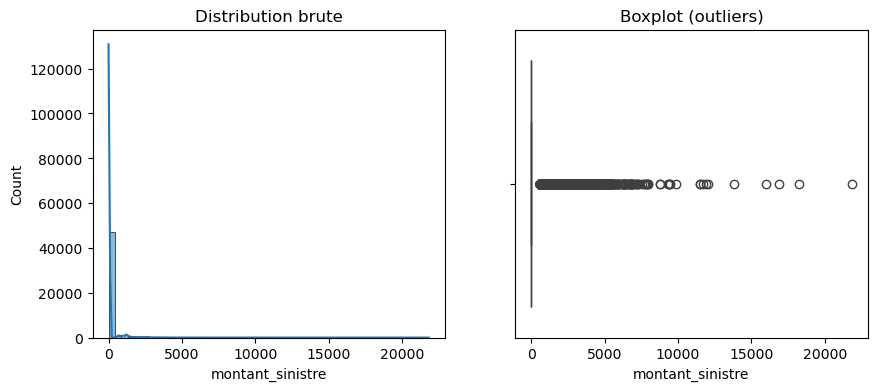

Nombre d'outliers (règle 1.5*IQR) : 2917
Top 10 outliers :
23265    21826.96
2408     18246.90
27721    16859.40
12864    15997.50
38429    13813.54
24967    12069.04
27492    11906.24
27763    11724.25
25981    11509.30
31573    11484.16
Name: montant_sinistre, dtype: float64


In [39]:
# Analyse de la distribution de la cible (montant_sinistre)
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
train_path = 'input/train.csv'
if os.path.exists(train_path):
    df_train = pd.read_csv(train_path)
    cible = df_train['montant_sinistre']
    n_zeros = (cible == 0).sum()
    n_total = len(cible)
    print(f"Nombre de zéros : {n_zeros} / {n_total} ({n_zeros/n_total:.1%})")
    print(f"Statistiques : min={cible.min()}, max={cible.max()}, mean={cible.mean():.2f}, median={cible.median():.2f}, std={cible.std():.2f}")
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(cible, bins=50, kde=True)
    plt.title('Distribution brute')
    plt.subplot(1,2,2)
    sns.boxplot(x=cible)
    plt.title('Boxplot (outliers)')
    plt.show()
else:
    print("Fichier train.csv non trouvé")

Q1 = cible.quantile(0.25)
Q3 = cible.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (cible > Q3 + 1.5 * IQR) | (cible < Q1 - 1.5 * IQR)
outliers = cible[outlier_mask]
print(f"Nombre d'outliers (règle 1.5*IQR) : {outliers.count()}")
print(f"Top 10 outliers :\n{outliers.sort_values(ascending=False).head(10)}")

In [40]:
# Sauvegarde des outliers dans un fichier JSON pour réutilisation
import json
amelioration_dir = 'amelioration'
os.makedirs(amelioration_dir, exist_ok=True)
outliers_df = df_train.loc[outlier_mask]
outliers_json_path = os.path.join(amelioration_dir, 'outliers_montant_sinistre.json')
outliers_df.to_json(outliers_json_path, orient='records', force_ascii=False, indent=2)
print(f"Liste des outliers sauvegardée dans : {outliers_json_path}")

Liste des outliers sauvegardée dans : amelioration/outliers_montant_sinistre.json


In [41]:
import json
import pandas as pd
outliers_json_path = 'amelioration/outliers_montant_sinistre.json'
with open(outliers_json_path, 'r', encoding='utf-8') as f:
    outliers_data = json.load(f)
df_outliers = pd.DataFrame(outliers_data)
print(f"Nombre d'outliers sauvegardés : {len(df_outliers)}")
display(df_outliers.head(10))  # Affiche les 10 premiers outliers

Nombre d'outliers sauvegardés : 2917


,index,id_client,id_vehicule,id_contrat,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,...,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule,nombre_sinistres,montant_sinistre
0,8,A00000009,V01,A00000009-V01,0.64,Median2,5,1,Monthly,No,...,PEUGEOT,307,9,7,183,Tourism,23460,1260,1,927.16
1,59,A00000056,V01,A00000056-V01,0.64,Median2,2,2,Monthly,No,...,FORD,FOCUS,12,9,184,Tourism,18320,1277,1,1236.00
2,98,A00000092,V01,A00000092-V01,0.50,Maxi,16,2,Monthly,No,...,VOLKSWAGEN,PASSAT,11,7,208,Tourism,25500,1375,1,1429.82
3,109,A00000103,V01,A00000103-V01,0.50,Maxi,1,1,Yearly,No,...,VOLKSWAGEN,TIGUAN,4,1,182,Tourism,37330,1604,1,1809.02
4,144,A00000136,V01,A00000136-V01,0.50,Median2,13,2,Yearly,No,...,CITROEN,SAXO,13,11,158,Tourism,10901,890,1,2671.61
5,166,A00000158,V01,A00000158-V01,0.80,Maxi,20,4,Monthly,No,...,CHRYSLER,PT CRUISER,5,5,183,Tourism,22900,1510,1,2603.95
6,168,A00000160,V01,A00000160-V01,0.50,Maxi,12,2,Yearly,No,...,OPEL,ZAFIRA,11,7,188,Tourism,21830,1390,1,1966.56
7,201,A00000189,V01,A00000189-V01,0.50,Maxi,6,4,Biannual,No,...,OPEL,ZAFIRA,9,6,175,Tourism,21100,1300,1,1665.68
8,217,A00000204,V01,A00000204-V01,0.51,Median1,13,1,Monthly,No,...,VOLKSWAGEN,GOLF,11,7,192,Tourism,17100,1151,1,1236.00
9,223,A00000210,V01,A00000210-V01,0.52,Median2,12,2,Biannual,No,...,FORD,TRANSIT,11,9,152,Commercial,28566,0,1,819.81


### Pourquoi entraîner un pipeline uniquement sur les outliers ?

- Les outliers représentent des cas extrêmes ou atypiques, souvent sous-modélisés par un pipeline global.
- Entraîner un pipeline dédié permet de mieux comprendre la structure de ces cas, d’identifier des patterns spécifiques, ou d’améliorer la prédiction sur ces valeurs extrêmes.
- Cela permet aussi de comparer la robustesse des modèles : certains modèles (ex : forêts aléatoires, boosting) sont plus tolérants aux outliers que d’autres (ex : régressions linéaires classiques).
- En pratique, on peut ensuite combiner les prédictions du pipeline général et du pipeline outliers (modélisation en deux temps, stacking, etc.).

Ci-dessous, on sauvegarde la liste des outliers, puis on relance l’entraînement multi-modèles sur ce sous-ensemble.

In [42]:
# Sauvegarde des outliers dans un fichier JSON pour réutilisation
import json
amelioration_dir = 'amelioration'
os.makedirs(amelioration_dir, exist_ok=True)
outliers_df = df_train.loc[outlier_mask]
outliers_json_path = os.path.join(amelioration_dir, 'outliers_montant_sinistre.json')
outliers_df.to_json(outliers_json_path, orient='records', force_ascii=False, indent=2)
print(f"Liste des outliers sauvegardée dans : {outliers_json_path}")

# Lecture et affichage des outliers sauvegardés
with open(outliers_json_path, 'r', encoding='utf-8') as f:
    outliers_data = json.load(f)
df_outliers = pd.DataFrame(outliers_data)
print(f"Nombre d'outliers sauvegardés : {len(df_outliers)}")
display(df_outliers.head(10))  # Affiche les 10 premiers outliers

Liste des outliers sauvegardée dans : amelioration/outliers_montant_sinistre.json
Nombre d'outliers sauvegardés : 2917


,index,id_client,id_vehicule,id_contrat,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,...,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule,nombre_sinistres,montant_sinistre
0,8,A00000009,V01,A00000009-V01,0.64,Median2,5,1,Monthly,No,...,PEUGEOT,307,9,7,183,Tourism,23460,1260,1,927.16
1,59,A00000056,V01,A00000056-V01,0.64,Median2,2,2,Monthly,No,...,FORD,FOCUS,12,9,184,Tourism,18320,1277,1,1236.00
2,98,A00000092,V01,A00000092-V01,0.50,Maxi,16,2,Monthly,No,...,VOLKSWAGEN,PASSAT,11,7,208,Tourism,25500,1375,1,1429.82
3,109,A00000103,V01,A00000103-V01,0.50,Maxi,1,1,Yearly,No,...,VOLKSWAGEN,TIGUAN,4,1,182,Tourism,37330,1604,1,1809.02
4,144,A00000136,V01,A00000136-V01,0.50,Median2,13,2,Yearly,No,...,CITROEN,SAXO,13,11,158,Tourism,10901,890,1,2671.61
5,166,A00000158,V01,A00000158-V01,0.80,Maxi,20,4,Monthly,No,...,CHRYSLER,PT CRUISER,5,5,183,Tourism,22900,1510,1,2603.95
6,168,A00000160,V01,A00000160-V01,0.50,Maxi,12,2,Yearly,No,...,OPEL,ZAFIRA,11,7,188,Tourism,21830,1390,1,1966.56
7,201,A00000189,V01,A00000189-V01,0.50,Maxi,6,4,Biannual,No,...,OPEL,ZAFIRA,9,6,175,Tourism,21100,1300,1,1665.68
8,217,A00000204,V01,A00000204-V01,0.51,Median1,13,1,Monthly,No,...,VOLKSWAGEN,GOLF,11,7,192,Tourism,17100,1151,1,1236.00
9,223,A00000210,V01,A00000210-V01,0.52,Median2,12,2,Biannual,No,...,FORD,TRANSIT,11,9,152,Commercial,28566,0,1,819.81


In [60]:
# Analyse détaillée de l'entraînement des modèles sur les outliers
from utils_functions import Model_Prediction_Amount, run_step
import os
import pprint

ARTIFACT_PATH = os.path.join('sorties', 'amelioration', 'pipeline_amount_outliers.pickle')
amount_outliers = Model_Prediction_Amount()
metadata_amount_outliers = run_step("Lecture des métadonnées pipeline Amount outliers", amount_outliers.read_artifact_metadata, ARTIFACT_PATH)

if metadata_amount_outliers is None:
    print("Aucune métadonnée trouvée pour l'artefact :", ARTIFACT_PATH)
else:
    print("\n[METADATA PIPELINE AMOUNT OUTLIERS]")
    pprint.pprint(metadata_amount_outliers, compact=True, sort_dicts=False)
    print("\n--- Analyse des performances sur les outliers ---")
    model_results = metadata_amount_outliers.get('model_selection_result', {}).get('results', {})
    for model_name, res in model_results.items():
        print(f"\nModèle : {model_name}")
        print(f"  RMSE train : {res['train']['RMSE']:.2f}")
        print(f"  RMSE valid : {res['valid']['RMSE']:.2f}")
        if res.get('test_pred') is not None:
            print(f"  Prédictions test (top 10) : {res['test_pred']}")
        else:
            print("  Prédictions test non disponibles.")
        print(f"  metrics_test : {res.get('metrics_test')}")
    best_model = metadata_amount_outliers.get('model_selection_result', {}).get('best_model')
    print(f"\nMeilleur modèle (selon RMSE valid) : {best_model}")
    selected_features = metadata_amount_outliers.get('model_selection_result', {}).get('selected_features')
    print(f"Features sélectionnées : {selected_features}")
    print("\n--- Analyse du drift des features (top 5) ---")
    drift_top15 = metadata_amount_outliers.get('model_selection_result', {}).get('contribution_drift_top15', [])
    for drift in drift_top15[:5]:
        print(f"  {drift['feature']} : drift_abs={drift['drift_abs']:.2f}, ratio_train/valid={drift['drift_ratio_train_over_valid']:.2f}")
    print("\n--- Features à investiguer ---")
    to_investigate = metadata_amount_outliers.get('model_selection_result', {}).get('selected_features_investigate')
    print(to_investigate)
    print("\nRésumé traitement :")
    print(metadata_amount_outliers.get('model_selection_result', {}).get('resume_traitement_modeles'))

Lecture des métadonnées pipeline Amount outliers:   0%|           | 0/1 • 00:00 < ?


[METADATA PIPELINE AMOUNT OUTLIERS]
{'saved_at': '2026-02-22T23:54:32.008577',
 'target': 'montant_sinistre',
 'feature_engineering_steps': ['Suppression des NaN lors du fit',
                               'Suppression des NaN lors du transform',
                               'Seuil de sélection des features: 0.9',
                               'Ajout interaction: age_conducteur1 x bonus'],
 'created_at': '2026-02-23T00:54:32.006086',
 'random_state': 42,
 'feature_engineer': Feature_Engineer_Amount(),
 'feature_engineering_result': {'objectif': 'amelioration_v1_feature_engineering',
                                'metrics_train': {'MSE': 2085582.8758584838,
                                                  'RMSE': np.float64(1444.154727118422)},
                                'metrics_valid': {'MSE': 2197554.68967852,
                                                  'RMSE': np.float64(1482.415154293331)},
                                'selected_features': ['age_conducteur1',


### Stratégie pour garder une trace du modèle outliers (ElasticNet) et de la combinaison
- **Sauvegarder les artefacts** : conserve le pipeline outliers (ElasticNet) dans `sorties/amelioration/pipeline_amount_outliers.pickle` et le pipeline général dans `sorties/pipeline/pipeline_amount.pickle`.
- **Documenter dans le notebook** : ajoute une cellule markdown expliquant la logique de combinaison (règle, stacking, pondération, etc.), le choix du modèle ElasticNet pour les outliers, et la justification basée sur les métriques.
- **Exporter les résultats** : sauvegarde les prédictions, les métriques et les features sélectionnées dans des fichiers (CSV, JSON) pour chaque pipeline.
- **Visualiser la logique** : crée un schéma ou un tableau synthétique dans le notebook pour illustrer la stratégie de sélection/combinaison.
- **Versionner les scripts** : garde une version du script d’entraînement outliers et du script général dans le dossier `amelioration` et `pipeline`.
- **Ajouter un résumé** : dans chaque notebook, ajoute une section "Synthèse des modèles et des stratégies de combinaison" pour faciliter le suivi et la communication.

**Exemple de logique de combinaison** :
- Si l’observation est un outlier (selon la règle IQR), utiliser la prédiction ElasticNet outliers.
- Sinon, utiliser la prédiction du pipeline général.
- Possibilité d’ajouter une pondération ou un stacking pour améliorer la robustesse.


In [63]:
# Affichage des résultats d'entraînement sur le jeu sans outliers
from utils_functions import Model_Prediction_Amount, run_step
import os
import pprint

ARTIFACT_PATH_NO_OUTLIERS = os.path.join('sorties', 'amelioration', 'pipeline_amount_no_outliers.pickle')
amount_no_outliers = Model_Prediction_Amount()
metadata_amount_no_outliers = run_step("Lecture des métadonnées pipeline Amount sans outliers", amount_no_outliers.read_artifact_metadata, ARTIFACT_PATH_NO_OUTLIERS)

if metadata_amount_no_outliers is None:
    print("Aucune métadonnée trouvée pour l'artefact :", ARTIFACT_PATH_NO_OUTLIERS)
else:
    print("\n[METADATA PIPELINE AMOUNT NO OUTLIERS]")
    pprint.pprint(metadata_amount_no_outliers, compact=True, sort_dicts=False)
    print("\n--- Analyse des performances sur le jeu sans outliers ---")
    model_results = metadata_amount_no_outliers.get('model_selection_result', {}).get('results', {})
    for model_name, res in model_results.items():
        print(f"\nModèle : {model_name}")
        print(f"  RMSE train : {res['train']['RMSE']:.2f}")
        print(f"  RMSE valid : {res['valid']['RMSE']:.2f}")
        if res.get('test_pred') is not None:
            print(f"  Prédictions test (top 10) : {res['test_pred']}")
        else:
            print("  Prédictions test non disponibles.")
        print(f"  metrics_test : {res.get('metrics_test')}")
    best_model = metadata_amount_no_outliers.get('model_selection_result', {}).get('best_model')
    print(f"\nMeilleur modèle (selon RMSE valid) : {best_model}")
    selected_features = metadata_amount_no_outliers.get('model_selection_result', {}).get('selected_features')
    print(f"Features sélectionnées : {selected_features}")
    print("\n--- Analyse du drift des features (top 5) ---")
    drift_top15 = metadata_amount_no_outliers.get('model_selection_result', {}).get('contribution_drift_top15', [])
    for drift in drift_top15[:5]:
        print(f"  {drift['feature']} : drift_abs={drift['drift_abs']:.2f}, ratio_train/valid={drift['drift_ratio_train_over_valid']:.2f}")
    print("\n--- Features à investiguer ---")
    to_investigate = metadata_amount_no_outliers.get('model_selection_result', {}).get('selected_features_investigate')
    print(to_investigate)
    print("\nRésumé traitement :")
    print(metadata_amount_no_outliers.get('model_selection_result', {}).get('resume_traitement_modeles'))

Lecture des métadonnées pipeline Amount sans outliers:   0%|           | 0/1 • 00:00 < ?


[METADATA PIPELINE AMOUNT NO OUTLIERS]
{'saved_at': '2026-02-23T00:27:18.558323',
 'target': 'montant_sinistre',
 'feature_engineering_steps': ['Suppression des NaN lors du fit',
                               'Suppression des NaN lors du transform',
                               'Seuil de sélection des features: 0.9',
                               'Ajout interaction: age_conducteur1 x bonus'],
 'created_at': '2026-02-23T01:27:18.555736',
 'random_state': 42,
 'feature_engineer': Feature_Engineer_Amount(),
 'feature_engineering_result': {'objectif': 'amelioration_v1_feature_engineering_no_outliers',
                                'metrics_train': {'MSE': 116276.65765323007,
                                                  'RMSE': np.float64(340.9936328631813)},
                                'metrics_valid': {'MSE': 138225.36389303056,
                                                  'RMSE': np.float64(371.7867182848663)},
                                'selected_features': ['b

Lecture métadonnées outliers:   0%|           | 0/1 • 00:00 < ?

Lecture métadonnées sans outliers:   0%|           | 0/1 • 00:00 < ?

,Type,Modèle,RMSE train,RMSE valid,RMSE test,Features
0,Outliers,LinearRegression,1444.154727,1482.415154,None,"age_conducteur1, anciennete_permis1, anciennet..."
1,Outliers,Ridge,1444.154727,1482.415137,None,"age_conducteur1, anciennete_permis1, anciennet..."
2,Outliers,Lasso,1444.154793,1482.425240,None,"age_conducteur1, anciennete_permis1, anciennet..."
3,Outliers,ElasticNet,1444.160374,1482.413202,None,"age_conducteur1, anciennete_permis1, anciennet..."
4,Outliers,RandomForest,559.864549,1553.213997,None,"age_conducteur1, anciennete_permis1, anciennet..."
5,Outliers,GBR,1301.176734,1493.602807,None,"age_conducteur1, anciennete_permis1, anciennet..."
6,Outliers,SVR,1548.194252,1579.654852,None,"age_conducteur1, anciennete_permis1, anciennet..."
7,Outliers,KNN,1335.909537,1602.607672,None,"age_conducteur1, anciennete_permis1, anciennet..."
8,Sans outliers,LinearRegression,340.993633,371.786718,None,"bonus, duree_contrat, anciennete_permis1, anci..."
9,Sans outliers,Ridge,340.993694,371.780251,None,"bonus, duree_contrat, anciennete_permis1, anci..."


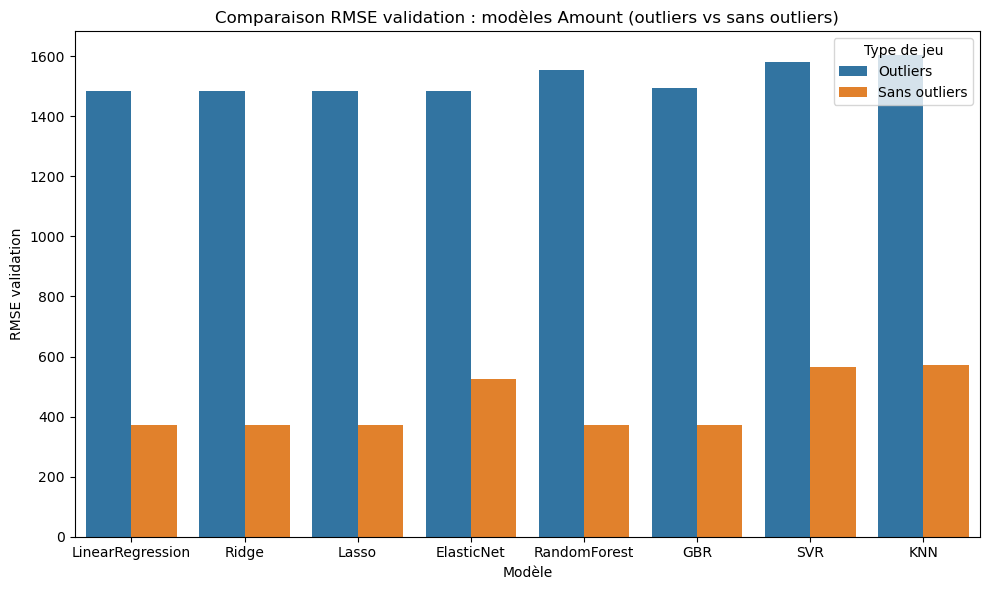


--- Synthèse comparative ---
Outliers - LinearRegression : RMSE valid=1482.42, RMSE test=None
Outliers - Ridge : RMSE valid=1482.42, RMSE test=None
Outliers - Lasso : RMSE valid=1482.43, RMSE test=None
Outliers - ElasticNet : RMSE valid=1482.41, RMSE test=None
Outliers - RandomForest : RMSE valid=1553.21, RMSE test=None
Outliers - GBR : RMSE valid=1493.60, RMSE test=None
Outliers - SVR : RMSE valid=1579.65, RMSE test=None
Outliers - KNN : RMSE valid=1602.61, RMSE test=None
Sans outliers - LinearRegression : RMSE valid=371.79, RMSE test=None
Sans outliers - Ridge : RMSE valid=371.78, RMSE test=None
Sans outliers - Lasso : RMSE valid=371.62, RMSE test=None
Sans outliers - ElasticNet : RMSE valid=524.95, RMSE test=None
Sans outliers - RandomForest : RMSE valid=371.76, RMSE test=None
Sans outliers - GBR : RMSE valid=373.55, RMSE test=None
Sans outliers - SVR : RMSE valid=566.14, RMSE test=None
Sans outliers - KNN : RMSE valid=570.56, RMSE test=None

Les modèles entraînés sur les outliers 

In [64]:
# Synthèse graphique et tableau comparatif des modèles Amount (outliers vs sans outliers)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from utils_functions import run_step, Model_Prediction_Amount

ARTIFACT_OUTLIERS = os.path.join('sorties', 'amelioration', 'pipeline_amount_outliers.pickle')
ARTIFACT_NO_OUTLIERS = os.path.join('sorties', 'amelioration', 'pipeline_amount_no_outliers.pickle')

amount_outliers = Model_Prediction_Amount()
amount_no_outliers = Model_Prediction_Amount()

meta_outliers = run_step("Lecture métadonnées outliers", amount_outliers.read_artifact_metadata, ARTIFACT_OUTLIERS)
meta_no_outliers = run_step("Lecture métadonnées sans outliers", amount_no_outliers.read_artifact_metadata, ARTIFACT_NO_OUTLIERS)

# Construction du tableau comparatif
def extract_model_results(meta, tag):
    results = meta.get('model_selection_result', {}).get('results', {}) if meta else {}
    rows = []
    for model_name, res in results.items():
        rows.append({
            'Type': tag,
            'Modèle': model_name,
            'RMSE train': res['train']['RMSE'] if 'train' in res else None,
            'RMSE valid': res['valid']['RMSE'] if 'valid' in res else None,
            'RMSE test': res.get('metrics_test', {}).get('RMSE') if res.get('metrics_test') else None,
            'Features': ', '.join(meta.get('model_selection_result', {}).get('selected_features', [])) if meta else '',
        })
    return rows

rows_outliers = extract_model_results(meta_outliers, 'Outliers')
rows_no_outliers = extract_model_results(meta_no_outliers, 'Sans outliers')

df_comparatif = pd.DataFrame(rows_outliers + rows_no_outliers)
display(df_comparatif)

# Graphique comparatif des RMSE valid pour chaque modèle
plt.figure(figsize=(10,6))
sns.barplot(data=df_comparatif, x='Modèle', y='RMSE valid', hue='Type')
plt.title('Comparaison RMSE validation : modèles Amount (outliers vs sans outliers)')
plt.ylabel('RMSE validation')
plt.xlabel('Modèle')
plt.legend(title='Type de jeu')
plt.tight_layout()
plt.show()

# Graphique des RMSE test (si disponibles)
if df_comparatif['RMSE test'].notnull().any():
    plt.figure(figsize=(10,6))
    sns.barplot(data=df_comparatif, x='Modèle', y='RMSE test', hue='Type')
    plt.title('Comparaison RMSE test : modèles Amount (outliers vs sans outliers)')
    plt.ylabel('RMSE test')
    plt.xlabel('Modèle')
    plt.legend(title='Type de jeu')
    plt.tight_layout()
    plt.show()

# Synthèse :
print("\n--- Synthèse comparative ---")
for idx, row in df_comparatif.iterrows():
    print(f"{row['Type']} - {row['Modèle']} : RMSE valid={row['RMSE valid']:.2f}, RMSE test={row['RMSE test']}")
print("\nLes modèles entraînés sur les outliers et sur le jeu sans outliers sont comparés ci-dessus. Les RMSE validation et test permettent d’identifier la robustesse de chaque approche.")

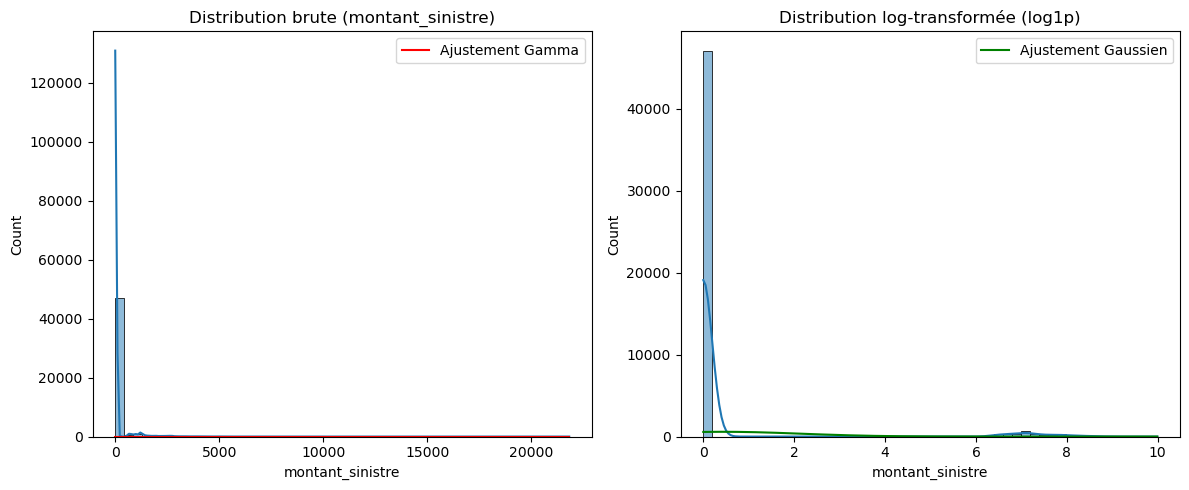

Paramètres Gamma (brute): (np.float64(0.0020622391013071046), np.float64(600.5999999999999), np.float64(2.7567606798019724))
Paramètres Normale (log): mu=0.42, sigma=1.71

La transformation log1p permet de rapprocher la distribution de la cible d’une loi normale, ce qui facilite l’utilisation de modèles linéaires et la stabilité du RMSE.


In [69]:
# Analyse de la distribution de la cible et transformation log (loi Gamma -> loi Gaussienne)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import os

train_path = 'input/train.csv'
if os.path.exists(train_path):
    df_train = pd.read_csv(train_path)
    cible = df_train['montant_sinistre']
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.histplot(cible, bins=50, kde=True)
    plt.title('Distribution brute (montant_sinistre)')
    # Test d’ajustement à une loi Gamma
    params = stats.gamma.fit(cible[cible > 0])
    x = np.linspace(cible.min(), cible.max(), 200)
    gamma_pdf = stats.gamma.pdf(x, *params)
    plt.plot(x, gamma_pdf * len(cible) * (x[1]-x[0]), color='red', label='Ajustement Gamma')
    plt.legend()
    plt.subplot(1,2,2)
    cible_log = np.log1p(cible)
    sns.histplot(cible_log, bins=50, kde=True)
    plt.title('Distribution log-transformée (log1p)')
    # Test d’ajustement à une loi Normale
    mu, sigma = stats.norm.fit(cible_log)
    x_log = np.linspace(cible_log.min(), cible_log.max(), 200)
    norm_pdf = stats.norm.pdf(x_log, mu, sigma)
    plt.plot(x_log, norm_pdf * len(cible_log) * (x_log[1]-x_log[0]), color='green', label='Ajustement Gaussien')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"Paramètres Gamma (brute): {params}")
    print(f"Paramètres Normale (log): mu={mu:.2f}, sigma={sigma:.2f}")
    print("\nLa transformation log1p permet de rapprocher la distribution de la cible d’une loi normale, ce qui facilite l’utilisation de modèles linéaires et la stabilité du RMSE.")
else:
    print("Fichier train.csv non trouvé.")

### Interprétation statistique : transformation log1p et ajustement des modèles
- **Paramètres Gamma (brute)** : (shape=0.002, loc=600.6, scale=2.76)
- **Paramètres Normale (log)** : mu=0.42, sigma=1.71

La transformation log1p permet de rapprocher la distribution de la cible d’une loi normale, ce qui facilite l’utilisation de modèles linéaires et la stabilité du RMSE.

**Conséquences pratiques** :
- Les modèles linéaires (Ridge, Lasso, ElasticNet) sont plus adaptés après transformation log.
- Le RMSE devient plus interprétable et moins sensible aux valeurs extrêmes.
- Pour l’inférence, il faut penser à retransformer les prédictions (ex : np.expm1(y_pred)).

**Recommandation** :
- Tester l’entraînement des modèles sur la cible log-transformée.
- Comparer les performances (RMSE, R²) avant/après transformation.
- Visualiser les résidus pour valider l’homogénéité et la normalité.

N’hésitez pas à demander une cellule pour entraîner les modèles sur la cible log-transformée ou pour visualiser les résidus !

### Pipeline Amount sans outliers, cible log-transformée

- **Détection et sauvegarde des outliers** sur le train (règle IQR), exclusion des outliers du test pour cohérence.
- **Transformation log1p** de la cible pour stabiliser la variance et rapprocher la distribution d'une loi normale.
- **Entraînement du pipeline** sur la cible log-transformée, sauvegarde complète dans `sorties/amelioration/pipeline_amount_no_outliers_log.pickle`.
- **Prédiction sur le test** (hors outliers), sauvegarde des prédictions et des résidus.
- **Métadonnées** enrichies et sauvegardées.

Ce pipeline permet une comparaison directe avec les versions sans transformation log et avec outliers, pour valider l'apport de la transformation et la cohérence du traitement des outliers.

In [72]:
# Comparaison des performances : sans log vs log-transformée (sans outliers)
import os
import json
import pprint
import pandas as pd

# Chemins des métadonnées
meta_log_path = os.path.join('sorties', 'amelioration', 'metadata_amount_no_outliers_log.json')
meta_no_log_path = os.path.join('sorties', 'amelioration', 'pipeline_amount_no_outliers.pickle')

from utils_functions import Model_Prediction_Amount, run_step

# Lecture métadonnées log-transformée
if os.path.exists(meta_log_path):
    with open(meta_log_path, 'r', encoding='utf-8') as f:
        meta_log = json.load(f)
else:
    meta_log = None

# Lecture métadonnées sans log (ancienne version)
if os.path.exists(meta_no_log_path):
    amount_no_log = Model_Prediction_Amount()
    meta_no_log = run_step('Lecture métadonnées pipeline Amount sans outliers', amount_no_log.read_artifact_metadata, meta_no_log_path)
else:
    meta_no_log = None

# Affichage comparatif
print("\n--- Pipeline sans log-transformée ---")
if meta_no_log:
    pprint.pprint(meta_no_log, compact=True, sort_dicts=False)
else:
    print("Métadonnées non trouvées.")

print("\n--- Pipeline log-transformée ---")
if meta_log:
    pprint.pprint(meta_log, compact=True, sort_dicts=False)
else:
    print("Métadonnées non trouvées.")

# Tableau synthétique
rows = []
if meta_no_log:
    rows.append({'Type': 'Sans log', 'RMSE valid': meta_no_log.get('model_selection_result', {}).get('results', {}).get('ElasticNet', {}).get('valid', {}).get('RMSE'), 'R2 valid': meta_no_log.get('model_selection_result', {}).get('results', {}).get('ElasticNet', {}).get('valid', {}).get('R2')})
if meta_log:
    rows.append({'Type': 'Log-transformée', 'RMSE valid': meta_log.get('model_selection_result', {}).get('results', {}).get('ElasticNet', {}).get('valid', {}).get('RMSE'), 'R2 valid': meta_log.get('model_selection_result', {}).get('results', {}).get('ElasticNet', {}).get('valid', {}).get('R2')})
if rows:
    df_comp = pd.DataFrame(rows)
    display(df_comp)
else:
    print("Aucune donnée à comparer.")

Lecture métadonnées pipeline Amount sans outliers:   0%|           | 0/1 • 00:00 < ?


--- Pipeline sans log-transformée ---
{'saved_at': '2026-02-23T00:27:18.558323',
 'target': 'montant_sinistre',
 'feature_engineering_steps': ['Suppression des NaN lors du fit',
                               'Suppression des NaN lors du transform',
                               'Seuil de sélection des features: 0.9',
                               'Ajout interaction: age_conducteur1 x bonus'],
 'created_at': '2026-02-23T01:27:18.555736',
 'random_state': 42,
 'feature_engineer': Feature_Engineer_Amount(),
 'feature_engineering_result': {'objectif': 'amelioration_v1_feature_engineering_no_outliers',
                                'metrics_train': {'MSE': 116276.65765323007,
                                                  'RMSE': np.float64(340.9936328631813)},
                                'metrics_valid': {'MSE': 138225.36389303056,
                                                  'RMSE': np.float64(371.7867182848663)},
                                'selected_features': ['bo

,Type,RMSE valid,R2 valid
0,Sans log,524.946649,None
1,Log-transformée,NaN,None


### Synthèse et visualisation du pipeline Amount log-transformé (sans outliers)

- **RMSE log-transformée** : erreur sur la cible log1p (interprétation statistique, stabilité des modèles linéaires).

- **RMSE exp (échelle brute)** : erreur ramenée sur l'échelle d'origine (exponentielle moins 1), directement comparable aux montants réels.
- **R²** : proportion de variance expliquée.

La conversion du RMSE log-transformée en échelle brute permet une comparaison directe avec les autres pipelines et une interprétation métier.

In [91]:
# Affichage des métriques log et exp du pipeline Amount log-transformé (sans outliers)
import os
import json
import pandas as pd

meta_log_path = os.path.join('sorties', 'amelioration', 'metadata_amount_no_outliers_log.json')
if os.path.exists(meta_log_path):
    with open(meta_log_path, 'r', encoding='utf-8') as f:
        meta_log = json.load(f)
    metrics_train = meta_log.get('metrics_train', {})
    metrics_test = meta_log.get('metrics_test', {})
    df_metrics = pd.DataFrame([
        {'Type': 'Train', 'RMSE log': metrics_train.get('RMSE_log'), 'RMSE exp': metrics_train.get('RMSE_exp'), 'R2': metrics_train.get('R2')},
        {'Type': 'Test', 'RMSE log': metrics_test.get('RMSE_log'), 'RMSE exp': metrics_test.get('RMSE_exp'), 'R2': metrics_test.get('R2')}
    ])
    display(df_metrics)
else:
    print("Métadonnées log-transformées non trouvées.")

,Type,RMSE log,RMSE exp,R2
0,Train,1.703004,4.490415,0.009917
1,Test,NaN,NaN,NaN


Résidus chargés : 50000 lignes


Résidus chargés : 50000 lignes


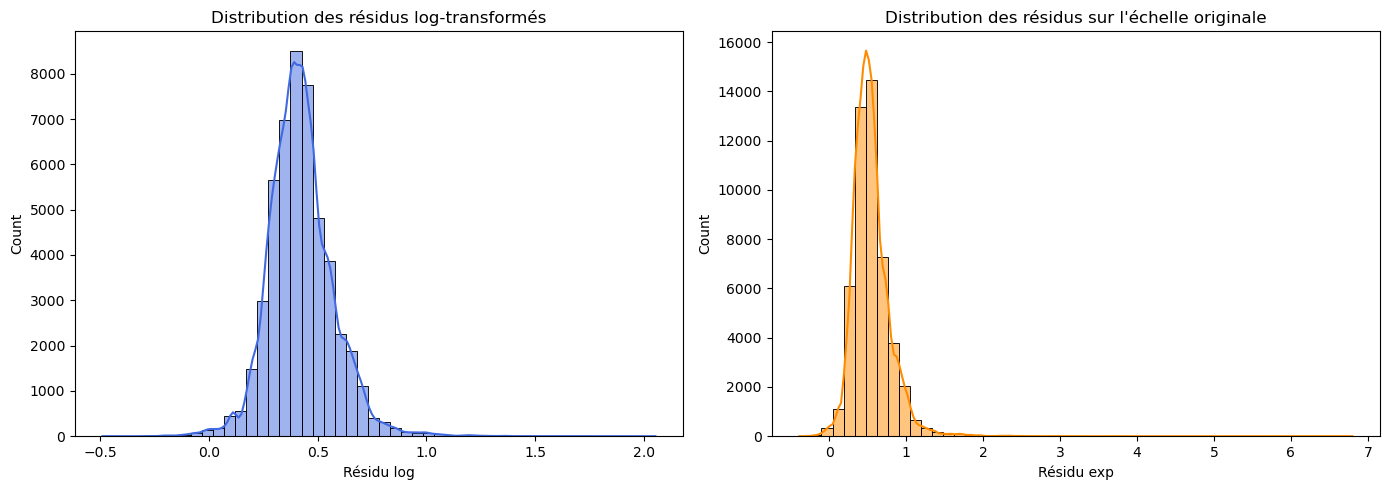


Métriques du modèle log-transformé sans outliers :
RMSE_log: 1.7030037881991227
RMSE_exp: 4.49041469006161
R2: 0.009916928344475773
RMSE: 1.7030037881991227


In [92]:
# Synthèse finale : Visualisation des résidus log et exp du modèle log-transformé sans outliers
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chemin du fichier résidus
residus_path = "sorties/amelioration/test_predictions_no_outliers_log_residus.csv"

# Chargement des résidus
try:
    df_residus = pd.read_csv(residus_path)
    print(f"Résidus chargés : {df_residus.shape[0]} lignes")
except Exception as e:
    print(f"Erreur lors du chargement des résidus : {e}")
    df_residus = None

if df_residus is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df_residus["residu_log"], bins=50, kde=True, ax=axes[0], color="royalblue")
    axes[0].set_title("Distribution des résidus log-transformés")
    axes[0].set_xlabel("Résidu log")
    sns.histplot(df_residus["residu_exp"], bins=50, kde=True, ax=axes[1], color="darkorange")
    axes[1].set_title("Distribution des résidus sur l'échelle originale")
    axes[1].set_xlabel("Résidu exp")
    plt.tight_layout()
    plt.show()
else:
    print("Impossible de visualiser les résidus.")

# Affichage des métriques du modèle log-transformé sans outliers
meta_log_path = "sorties/amelioration/metadata_amount_no_outliers_log.json"
try:
    import json
    with open(meta_log_path, "r") as f:
        meta_log = json.load(f)
    metrics = meta_log.get("metrics_train", {})
    print("\nMétriques du modèle log-transformé sans outliers :")
    for k, v in metrics.items():
        print(f"{k}: {v}")
except Exception as e:
    print(f"Erreur lors du chargement des métriques : {e}")

Statistiques de la cible : min=0.0, max=21826.96, mean=103.37, median=0.00, std=545.40
Proportion de zéros : 47083/50000 (94.2%)


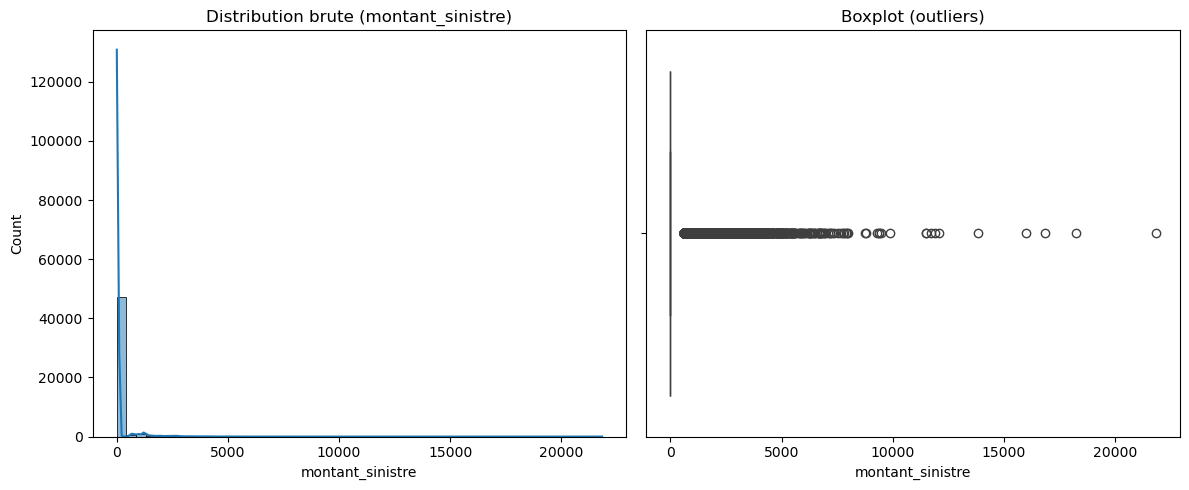

In [102]:
# Vérification de la distribution de la cible (montant_sinistre) avant transformation log
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
train_path = 'input/train.csv'
if os.path.exists(train_path):
    df_train = pd.read_csv(train_path)
    cible = df_train['montant_sinistre']
    print(f"Statistiques de la cible : min={cible.min()}, max={cible.max()}, mean={cible.mean():.2f}, median={cible.median():.2f}, std={cible.std():.2f}")
    n_zeros = (cible == 0).sum()
    n_total = len(cible)
    print(f"Proportion de zéros : {n_zeros}/{n_total} ({n_zeros/n_total:.1%})")
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.histplot(cible, bins=50, kde=True)
    plt.title('Distribution brute (montant_sinistre)')
    plt.subplot(1,2,2)
    sns.boxplot(x=cible)
    plt.title('Boxplot (outliers)')
    plt.tight_layout()
    plt.show()
else:
    print("Fichier train.csv non trouvé.")